# Отчет по экспериментам PLUM-style MovieLens-1M

Дата сборки: `2026-04-21 18:18:30`  
Репозиторий: `C:\Users\User\plum-ml1m-repro`

Этот notebook создан и выполнен автоматически из локальных артефактов проекта: `runs/`, `data/processed/artifacts/CPT_user_behavior_V1/`, `data/processed/artifacts/SFT/`, `data/processed/splits/`.

Цель отчета: честно зафиксировать, что получилось на стадиях **Semantic ID / RQ-VAE**, **CPT**, **SFT**, где пайплайн рабочий, а где текущая серия экспериментов не проходит минимальный baseline-контроль.


## Executive Summary

1. **Самая сильная часть проекта сейчас - Semantic ID stage.** Экспортированные `SIDs_V1` имеют `3519` уникальных SID tuple из `3706` items: **94.95%**, collision excess `187`.
2. **CPT stage технически выполнен на нескольких GPT-2/GPT-2 Medium ветках.** Лучший найденный CPT eval loss по trainer states: `0.9599` у `cpt_gpt2-medium_v1_overkill/checkpoint-1000`. Это полезно как domain adaptation, но само по себе не доказывает recommendation quality.
3. **SFT stage работает технически, но текущая серия является negative result.** Medium SFT на val-probe дает лучший `Recall@10 = 0.0381`, тогда как простой popularity baseline на том же probe дает `Recall@10 = 0.0508`.
4. **Продолжать эту же серию без смены постановки нерационально.** Следующий осмысленный шаг: зафиксировать negative result, добавить сильные sequential baselines и только потом запускать новую SFT-серию с full sliding-window supervision, `MAX_LENGTH=1024`, честным `RECSYS_BEAMS >= 20` и контролем diversity.


In [1]:
# Re-runnable setup for this report notebook.
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

NOTEBOOK_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_ROOT))

from scripts.reporting import generate_experiments_report_notebook as report

ROOT = report.ROOT
bundle = report.load_dataset_bundle()
dataset_facts = bundle["dataset_facts"]
split_summary = bundle["split_summary"]
target_distribution = bundle["target_distribution"]
rqvae_summary = report.collect_rqvae_runs()
cpt_summary = report.collect_cpt_runs()
sft_metrics, sft_diagnostics = report.collect_sft_runs(bundle)
medium_epoch_path = report.SFT_DIR / "sft_gpt2_medium_plus_plus_plus_monitor" / "logs" / "epoch_metrics.json"
medium_epochs = pd.DataFrame(report.read_json(medium_epoch_path)) if medium_epoch_path.exists() else pd.DataFrame()

def show_png(path):
    display(Image(filename=str(path)))

{
    "root": str(ROOT),
    "rqvae_runs": len(rqvae_summary),
    "cpt_checkpoints": len(cpt_summary),
    "sft_metric_rows": len(sft_metrics),
}

{'root': 'C:\\Users\\User\\plum-ml1m-repro', 'rqvae_runs': 13, 'cpt_checkpoints': 18, 'sft_metric_rows': 8}

## 1. Данные, splits и SID-качество

In [2]:
# Train/val/test split summary.
split_summary

split,rows,users,items
train,988129,6040,3704
val,6040,6040,1951
test,6040,6040,1874


**Комментарий.** Сплит хронологический leave-last-two на пользователя: `train` содержит почти все взаимодействия, `val` - предпоследний item, `test` - последний item. Это корректный базовый протокол для next-item recommendation. Медианная train-history длина: `94` events; 90-й процентиль: `398` events. При текущем SFT `MAX_LENGTH=512` в prompt реально помещается существенно меньше 100 событий.


In [3]:
# Факты по SID и истории пользователей.
dataset_facts

{
  "train_rows": 988129,
  "val_rows": 6040,
  "test_rows": 6040,
  "users": 6040,
  "items": 3706,
  "unique_sids": 3519,
  "sid_uniqueness": 0.9495412844036697,
  "sid_collision_buckets": 98,
  "sid_collided_items": 285,
  "sid_collision_excess": 187,
  "history_len_median": 94.0,
  "history_len_mean": 163.5975165562914,
  "history_len_p90": 398.0,
  "history_len_max": 2312
}


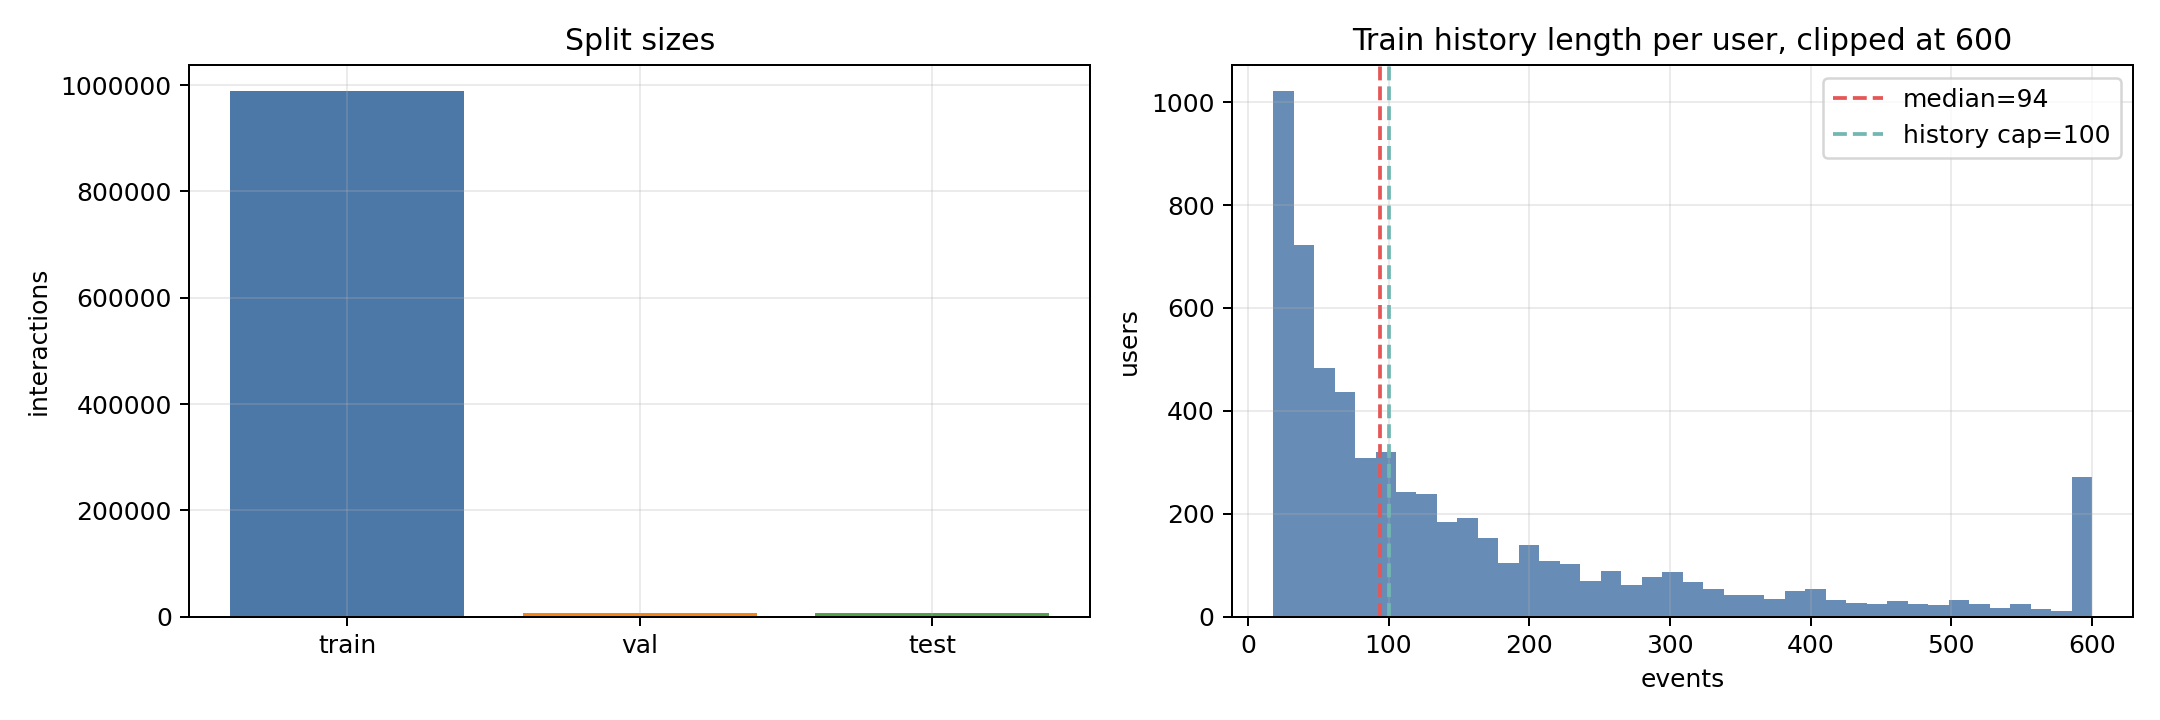

In [4]:
# Распределение размеров splits и длины пользовательской истории.
show_png(report.plot_dataset(bundle))

In [5]:
# Насколько target distribution сконцентрирован по популярным items.
target_distribution

split,n,unique_items,top10_share,top20_share,top100_share
train,988129,3704,0.028142,0.052146,0.183239
val,6040,1951,0.043212,0.073179,0.224503
test,6040,1874,0.054139,0.089073,0.256623


## 2. RQ-VAE / Semantic ID эксперименты

Здесь собраны все `runs/*/metrics.json`, где были метрики RQ-VAE. Для PLUM-like пайплайна самый важный критерий на этой стадии - не только reconstruction loss, но и **уникальность SID tuple**, потому что генеративный recommender должен маппить сгенерированный SID обратно в конкретный item.

Лучший экспортированный результат проекта: `SIDs_V1.npy`, uniqueness **94.95%**. По локальным run logs лучший RQ-VAE-кандидат: `5codebooks_10k_epochs` с max logged uniqueness `94.9541%`.


In [6]:
# RQ-VAE runs sorted by best observed full-SID uniqueness.
rqvae_summary

run,n_levels,epochs_logged,best_val_loss,best_sid_uniqueness_pct,last_sid_uniqueness_pct,quality_note,path
5codebooks_10k_epochs,5,20000,0.8616,94.9541,91.3384,candidate SID export,runs\5codebooks_10k_epochs
4codebooks_10k_epochs,4,26000,2.5809,91.5542,67.8359,candidate SID export,runs\4codebooks_10k_epochs
bucket1,3,12000,0.9465,83.6481,53.3729,strong SID run,runs\bucket1
RQVAE + L_con + Progressive Masking,3,400,0.0051,NaN,NaN,diagnostic/weak,runs\RQVAE + L_con + Progressive Masking
Rubish,3,80,0.2100,NaN,NaN,diagnostic/weak,runs\Rubish
baseline_rqvae,3,400,0.6377,NaN,NaN,diagnostic/weak,runs\baseline_rqvae
2026-01-19_17-53-26_baseline_rqvae_title_year_genres,3,400,1.0922,NaN,NaN,diagnostic/weak,runs\2026-01-19_17-53-26_baseline_rqvae_title_year_genres
RQVAE_ProgressiveMasking_ContrastiveRegularization,3,400,1.4795,NaN,NaN,diagnostic/weak,runs\RQVAE_ProgressiveMasking_ContrastiveRegularization
test,3,400,1.4795,NaN,NaN,diagnostic/weak,runs\test
2026-01-20_11-28-28_rqvae_title_year_genres_NAIVE_MASKING,3,400,1.6846,NaN,NaN,diagnostic/weak,runs\2026-01-20_11-28-28_rqvae_title_year_genres_NAIVE_MASKING


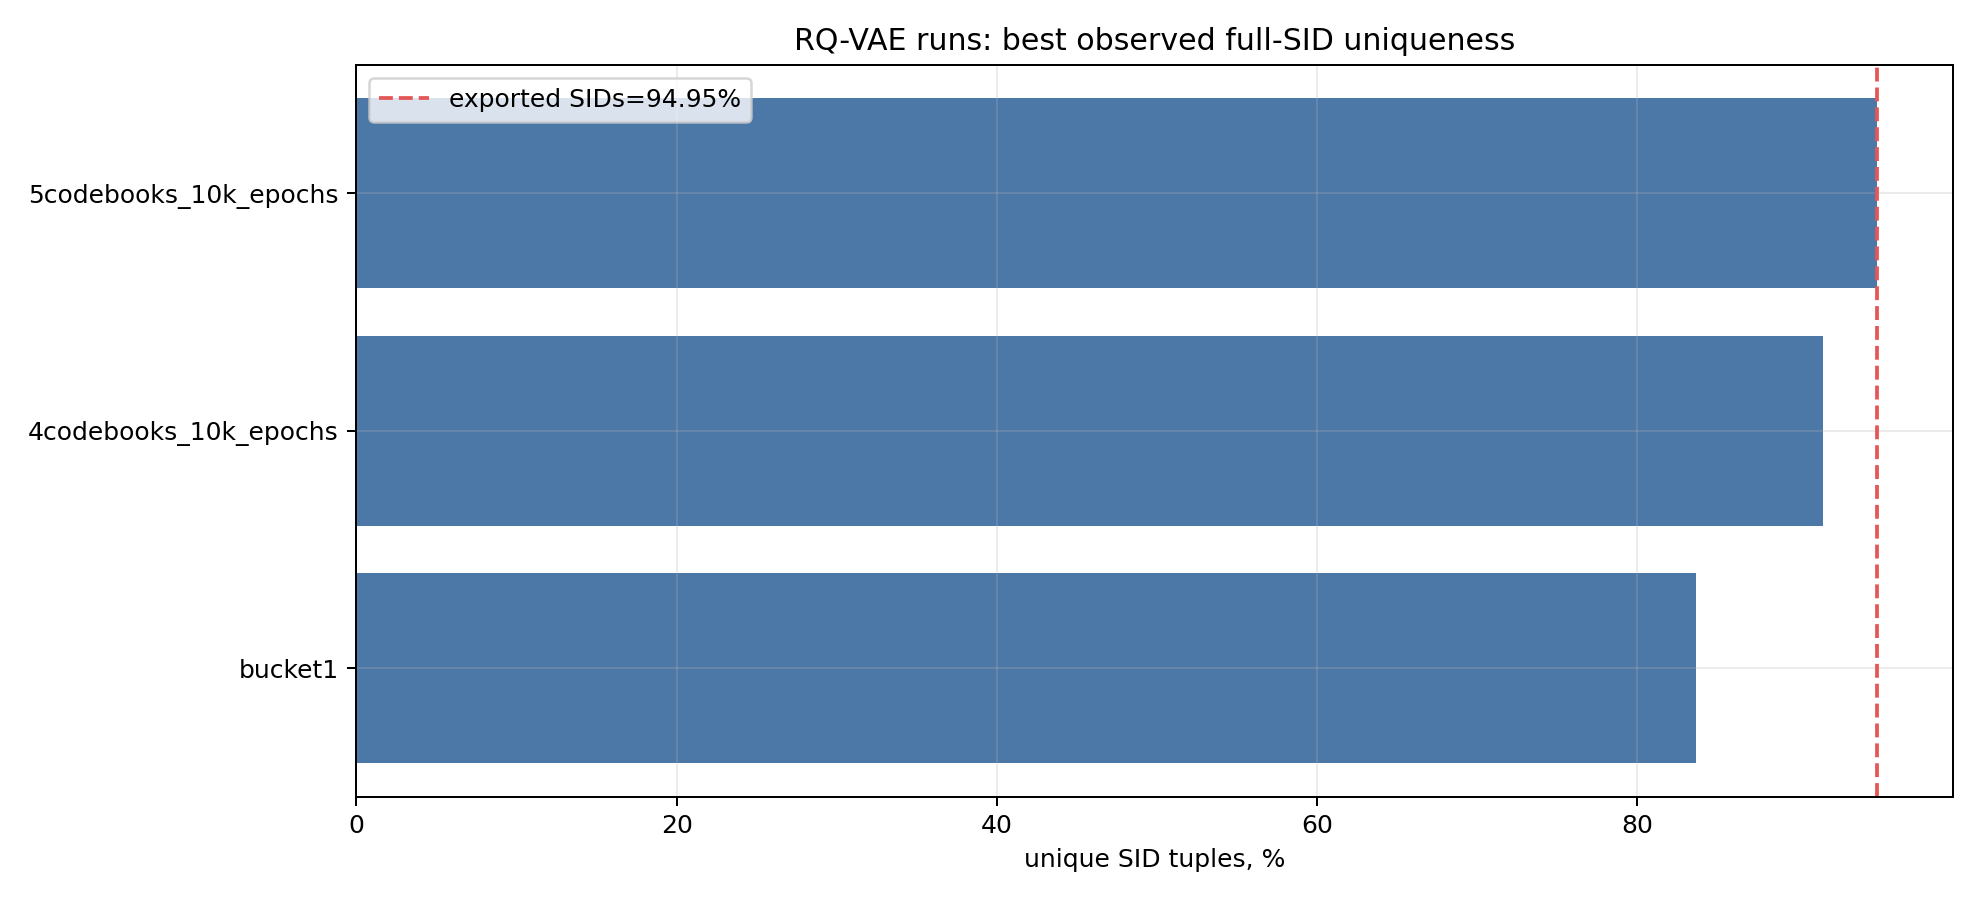

In [7]:
# Сравнение лучших RQ-VAE runs по SID uniqueness.
show_png(report.plot_rqvae(rqvae_summary, exported_sid_uniqueness=dataset_facts["sid_uniqueness"]))

**Комментарий.** RQ-VAE stage можно считать наиболее зрелой частью проекта: есть progression от слабых 3-level/старых runs к 5-level SID с высокой уникальностью. При этом это не полная PLUM SID-v2 реализация: MovieLens не имеет production-видео модальностей, а признаки являются суррогатом из title/year/genres.

## 3. CPT эксперименты GPT-2 / GPT-2 Medium

CPT-чекпоинты извлечены из `trainer_state.json`. Эта стадия проверяет, что LLM адаптировалась к SID/user/history/metadata токенам. Важно: **CPT loss нельзя интерпретировать как recommendation metric**. Это language-model objective на смеси behavior и metadata corpus.

In [8]:
# CPT checkpoints discovered from trainer_state.json.
cpt_summary

run,checkpoint,family,global_step,epoch,best_eval_loss,last_train_loss,path
cpt_gpt2_v1,checkpoint-1200,base,1200,3.2432,1.7661,1.9273,data\processed\artifacts\CPT_user_behavior_V1\cpt_gpt2_v1\checkpoint-1200
cpt_gpt2_v1,checkpoint-1400,base,1400,3.7838,1.7187,1.8746,data\processed\artifacts\CPT_user_behavior_V1\cpt_gpt2_v1\checkpoint-1400
cpt_gpt2_v1_plus,checkpoint-1200,base,1200,3.2432,1.1765,1.2942,data\processed\artifacts\CPT_user_behavior_V1\cpt_gpt2_v1_plus\checkpoint-1200
cpt_gpt2_v1_plus,checkpoint-1400,base,1400,3.7838,1.1684,1.2739,data\processed\artifacts\CPT_user_behavior_V1\cpt_gpt2_v1_plus\checkpoint-1400
cpt_gpt2_v1_plus_plus,checkpoint-800,base,800,2.1622,1.1033,1.1649,data\processed\artifacts\CPT_user_behavior_V1\cpt_gpt2_v1_plus_plus\checkpoint-800
cpt_gpt2_v1_plus_plus,checkpoint-1000,base,1000,2.7027,1.0960,1.1485,data\processed\artifacts\CPT_user_behavior_V1\cpt_gpt2_v1_plus_plus\checkpoint-1000
cpt_gpt2_v1_plus_plus_plus,checkpoint-1000,base,1000,2.3495,1.1145,1.1696,data\processed\artifacts\CPT_user_behavior_V1\cpt_gpt2_v1_plus_plus_plus\checkpoint-1000
cpt_gpt2_v1_plus_plus_plus,checkpoint-1200,base,1200,2.8194,1.1071,1.1521,data\processed\artifacts\CPT_user_behavior_V1\cpt_gpt2_v1_plus_plus_plus\checkpoint-1200
cpt_gpt2-medium_v1,checkpoint-2000,medium,2000,2.7027,1.6309,1.7695,data\processed\artifacts\CPT_user_behavior_V1\cpt_gpt2-medium_v1\checkpoint-2000
cpt_gpt2-medium_v1_overkill,checkpoint-800,medium,800,2.1150,0.9626,0.9544,data\processed\artifacts\CPT_user_behavior_V1\cpt_gpt2-medium_v1_overkill\checkpoint-800


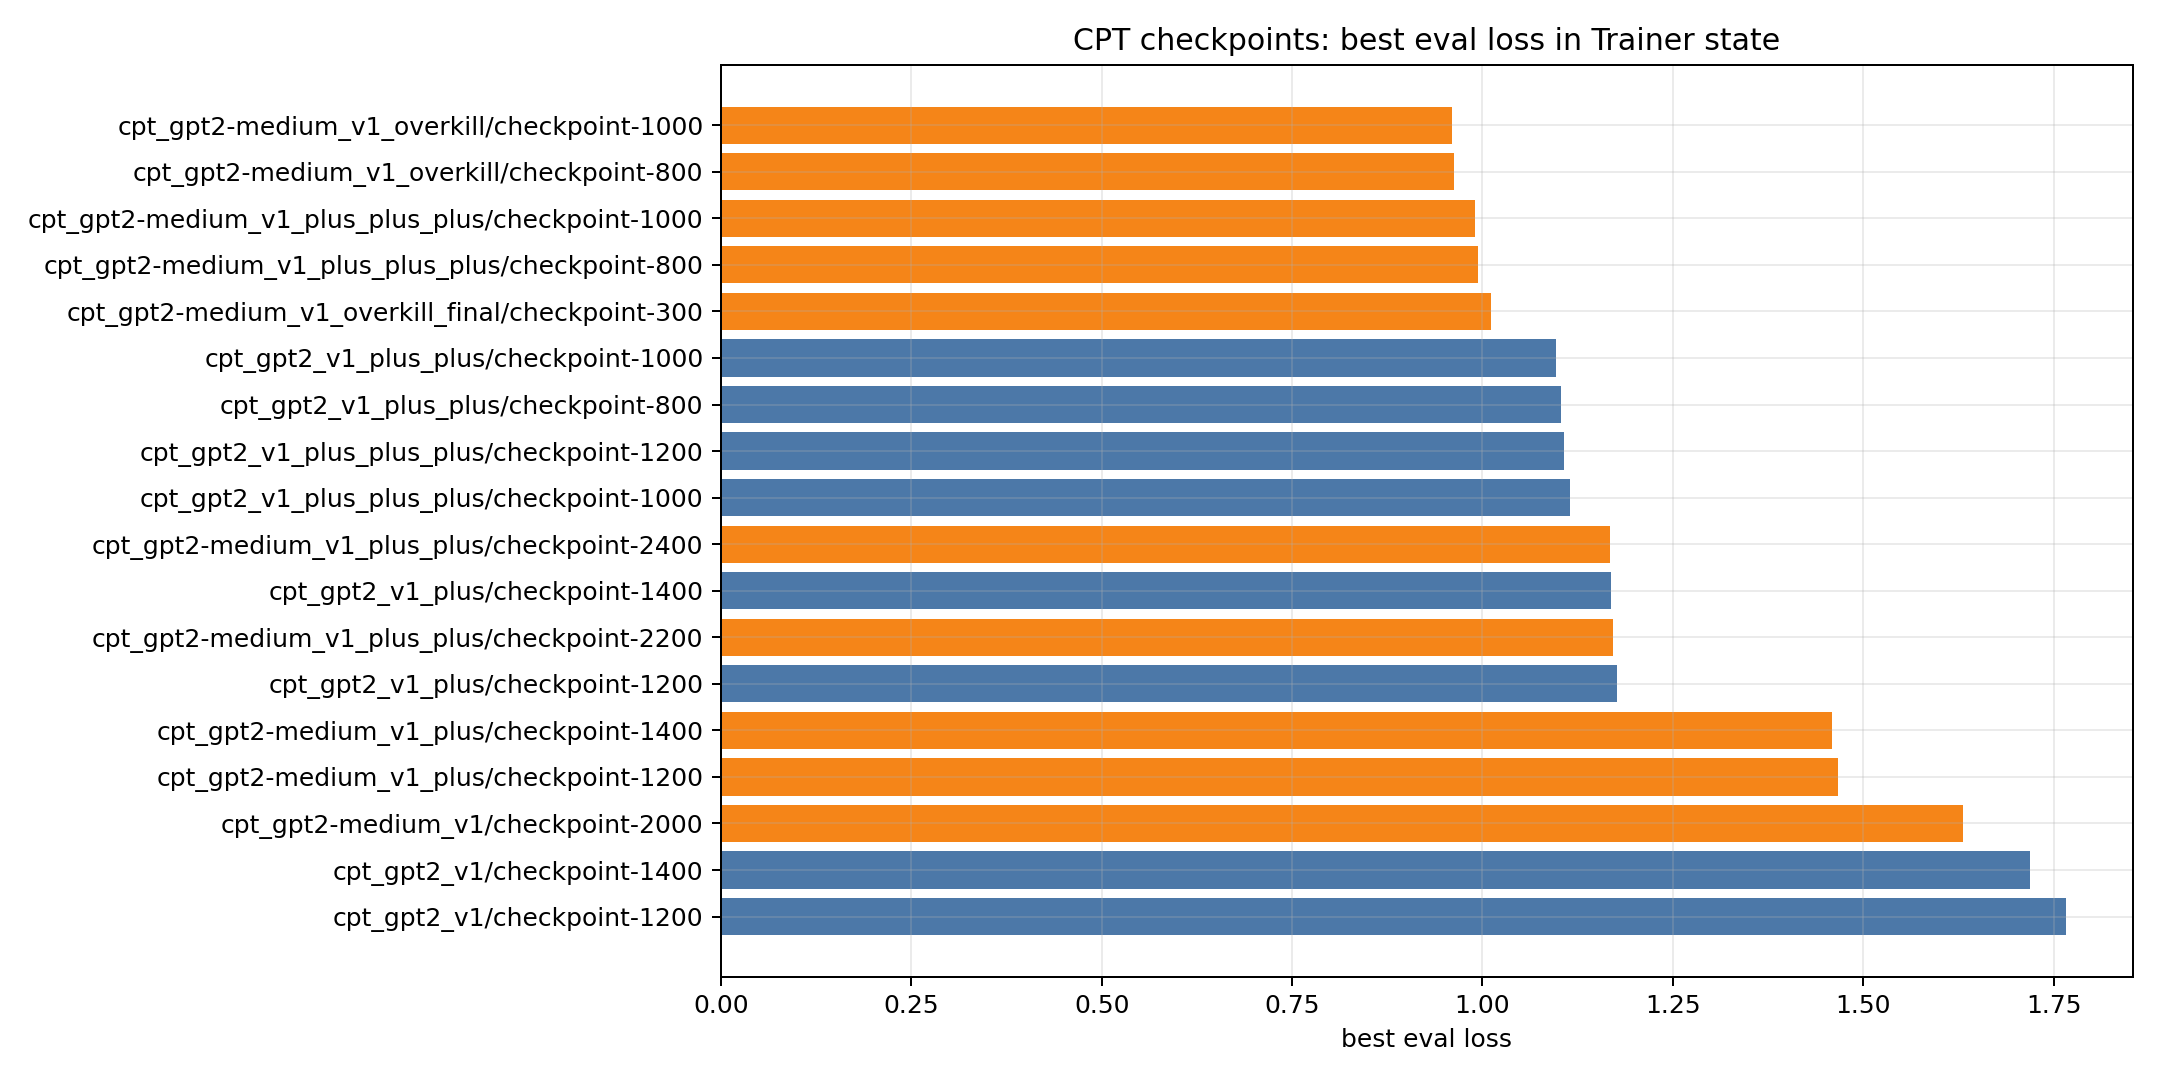

In [9]:
# Best CPT eval losses by checkpoint.
show_png(report.plot_cpt(cpt_summary))

**Комментарий.** По CPT видно, что серия GPT-2 Medium дошла до низких eval losses, но SFT результаты ниже показывают: хороший CPT loss не гарантирует хороший next-item ranking. Для отчета это важный разделитель: *domain adaptation happened*, но *recommendation quality still not solved*.

## 4. SFT и baseline-контроль

SFT должен отвечать на главный вопрос: генерирует ли модель SID следующего item лучше простых baseline. Здесь сравниваются:

- `Popularity`: рекомендуем самые популярные unseen items.
- `sft_gpt2_s_weak_cpt_3epochs`: старый full val/test запуск GPT-2 base.
- `sft_gpt2_medium_plus_plus_plus_monitor`: свежий GPT-2 Medium SFT, пока только epoch monitor на 1024 val examples.

Критическая проверка: Medium SFT на том же val-probe проигрывает popularity baseline по Recall@10 и Recall@20.

In [10]:
# SFT and popularity metrics.
sft_metrics

experiment,stage,scope,n,recall@10,recall@20,ndcg@10,ndcg@20,item_coverage
popularity_full_val,baseline,full_val,6040.0,0.0427,0.0707,0.0206,0.0276,20.0
popularity_val_probe_1024,baseline,val_probe_1024,1024.0,0.0508,0.0811,0.0263,0.0339,20.0
popularity_full_test,baseline,full_test,6040.0,0.0369,0.0682,0.0180,0.0258,20.0
sft_gpt2_s_weak_cpt_3epochs,SFT,full_val,6040.0,0.0253,0.0334,0.0136,0.0156,182.0
sft_gpt2_s_weak_cpt_3epochs,SFT,full_test,6040.0,0.0217,0.0281,0.0119,0.0136,185.0
sft_gpt2_medium_plus_plus_plus_monitor,SFT,val_probe_epoch_01,1024.0,0.0361,0.0410,0.0204,0.0216,248.0
sft_gpt2_medium_plus_plus_plus_monitor,SFT,val_probe_epoch_02,1024.0,0.0332,0.0410,0.0194,0.0214,275.0
sft_gpt2_medium_plus_plus_plus_monitor,SFT,val_probe_epoch_03,1024.0,0.0381,0.0439,0.0211,0.0226,271.0


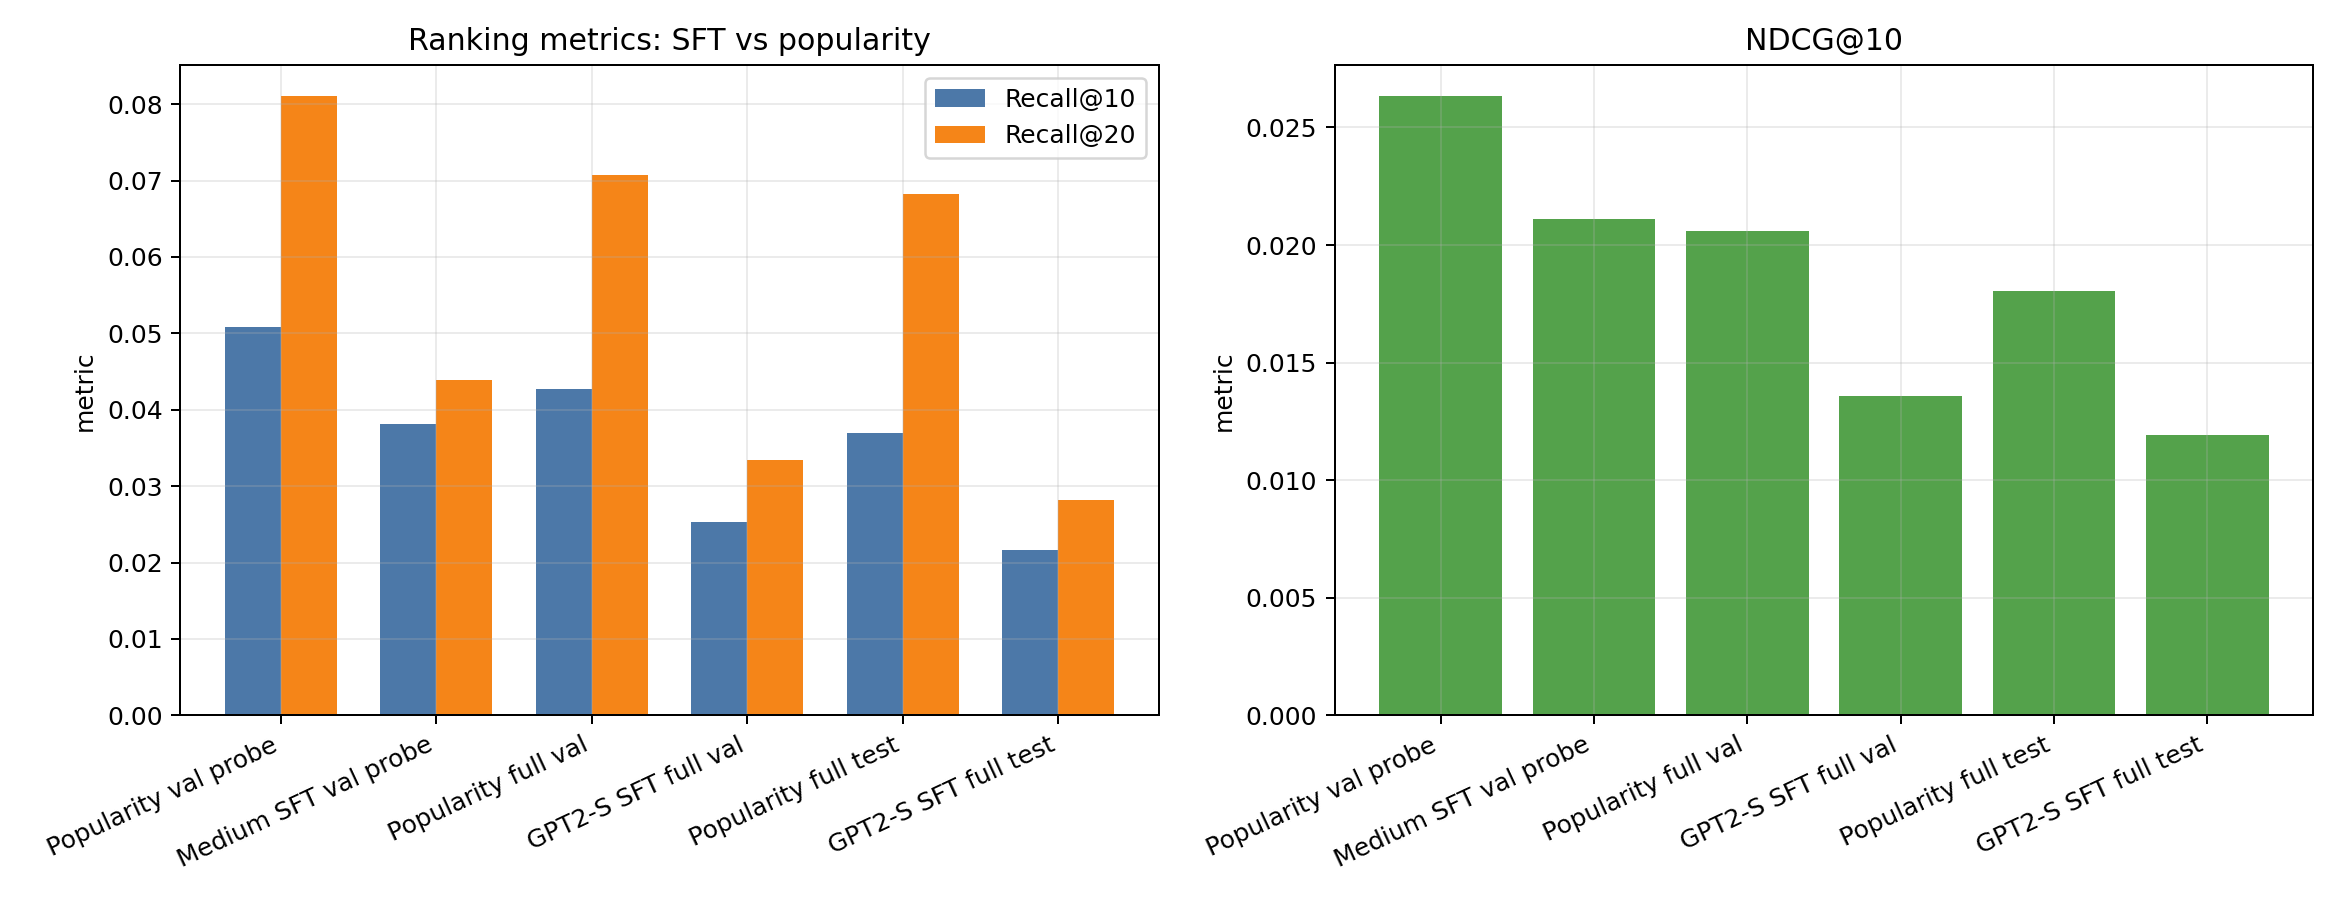

In [11]:
# SFT vs popularity baseline.
show_png(report.plot_sft_metrics(sft_metrics))

**Комментарий.** На val-probe:

- Popularity `Recall@10 = 0.0508`;
- Medium SFT epoch-03 `Recall@10 = 0.0381`;
- Popularity `Recall@20 = 0.0811`;
- Medium SFT epoch-03 `Recall@20 = 0.0439`.

Это объективно слабый результат. Дополнительно `Recall@20` у Medium monitor занижен/некорректен из-за `RECSYS_BEAMS=10` при `TOP_K=20`; но даже честный `Recall@10` уже ниже baseline.


## 5. Medium SFT epoch monitor

In [12]:
# Epoch-level monitor for GPT-2 Medium SFT.
medium_epochs

epoch,global_step,train_loss_last,teacher_forcing_eval_loss,epoch_eval_seconds,peak_vram_reserved_gb,peak_vram_allocated_gb,best_epoch,best_metric,bad_epochs,n,recall@1,ndcg@1,mrr@1,recall@5,ndcg@5,mrr@5,recall@10,ndcg@10,mrr@10,recall@20,ndcg@20,mrr@20,invalid_sid_rate,duplicate_rate,item_coverage
1,839,1.664357,1.387263,268.465321,14.414062,13.847288,1,0.036133,0,1024.0,0.008789,0.008789,0.008789,0.025391,0.017059,0.014339,0.036133,0.020416,0.015655,0.041016,0.021629,0.015976,0.0,0.0,248.0
2,1678,1.550690,1.337253,311.887049,14.437500,13.851322,1,0.036133,1,1024.0,0.006836,0.006836,0.006836,0.027344,0.017578,0.014339,0.033203,0.019375,0.015025,0.041016,0.021397,0.015606,0.0,0.0,275.0
3,2517,1.485380,1.321097,547.635777,14.437500,13.847516,3,0.038086,0,1024.0,0.005859,0.005859,0.005859,0.031250,0.019010,0.014974,0.038086,0.021124,0.015790,0.043945,0.022637,0.016221,0.0,0.0,271.0


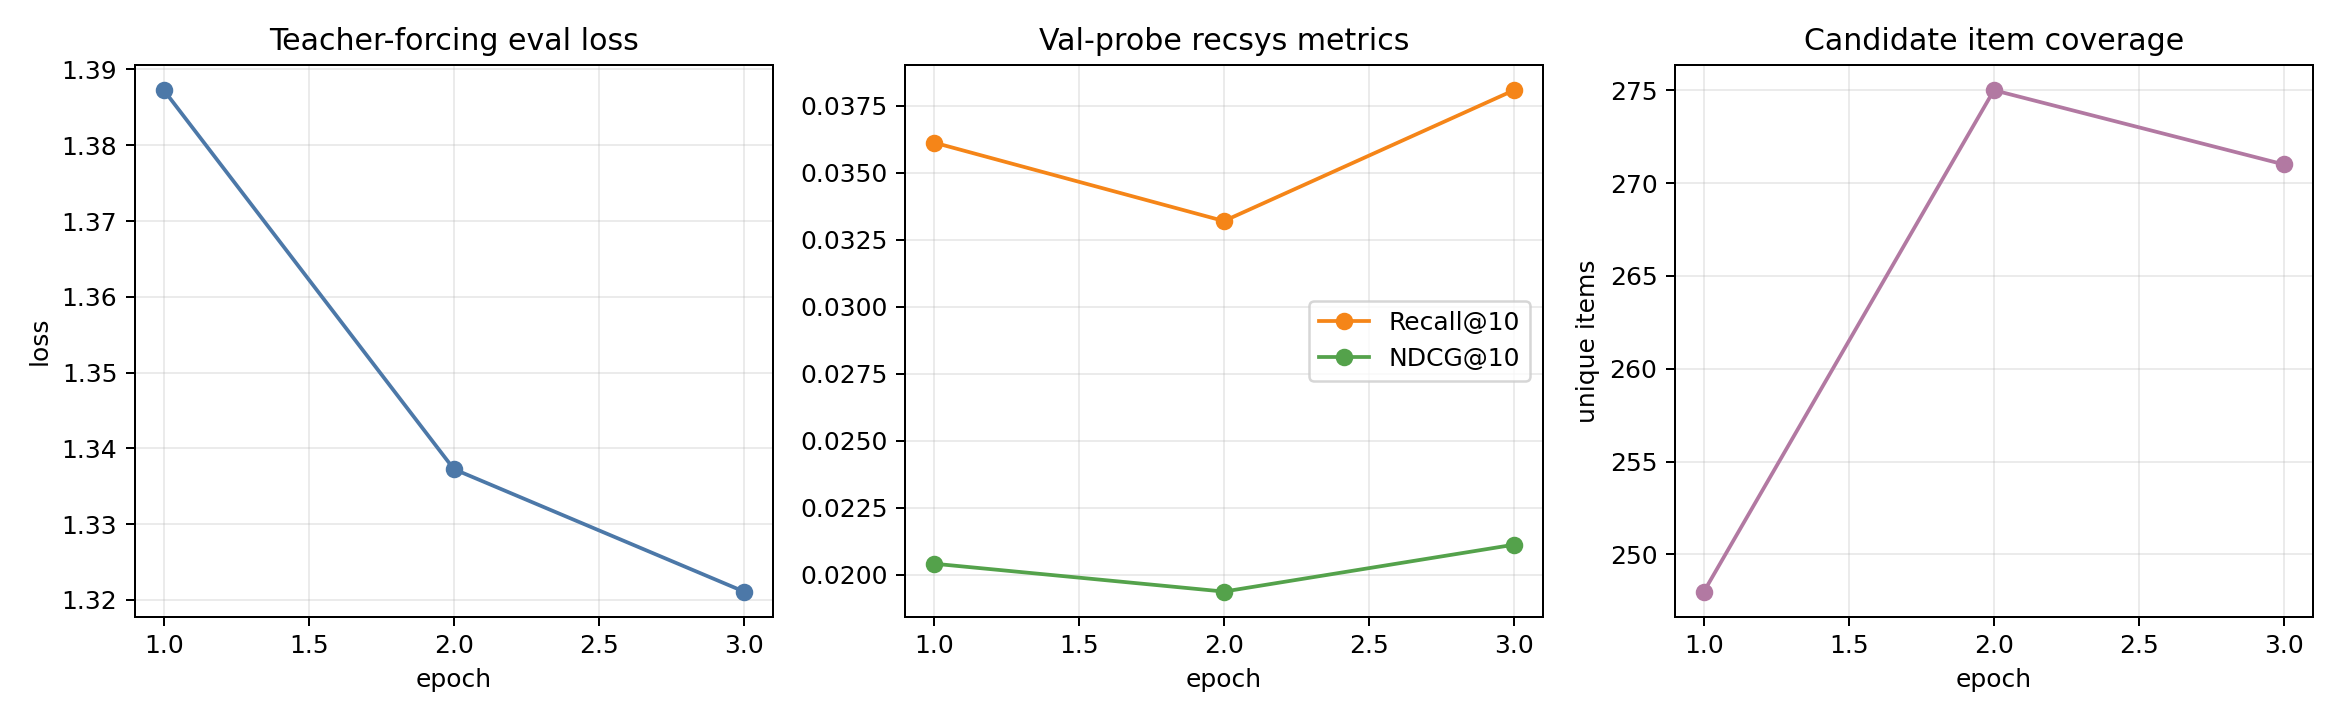

In [13]:
# Loss decreases, ranking barely moves.
show_png(report.plot_sft_epochs(medium_epochs))

In [14]:
# Generation diagnostics: candidate list length, coverage, concentration.
sft_diagnostics

experiment,scope,invalid_sid_rate,duplicate_rate,item_coverage,decode_seconds,candidate_len_mean,candidate_len_lt_20,top1_unique,top1_top10_share,best_eval_loss,last_train_loss,global_step
sft_gpt2_s_weak_cpt_3epochs,full_val,0.0,0.0,182.0,1493.385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sft_gpt2_s_weak_cpt_3epochs,full_test,0.0,0.0,185.0,1541.431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sft_gpt2_medium_plus_plus_plus_monitor,val_probe_epoch_01,0.0,0.0,248.0,NaN,16.0928,439.0,86.0,0.6494,NaN,NaN,NaN
sft_gpt2_medium_plus_plus_plus_monitor,val_probe_epoch_02,0.0,0.0,275.0,NaN,16.2490,474.0,89.0,0.5850,NaN,NaN,NaN
sft_gpt2_medium_plus_plus_plus_monitor,val_probe_epoch_03,0.0,0.0,271.0,NaN,15.4756,535.0,96.0,0.5557,NaN,NaN,NaN
sft_tiny_gpt2_smoke_100steps,smoke,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.8035,10.8042,100.0


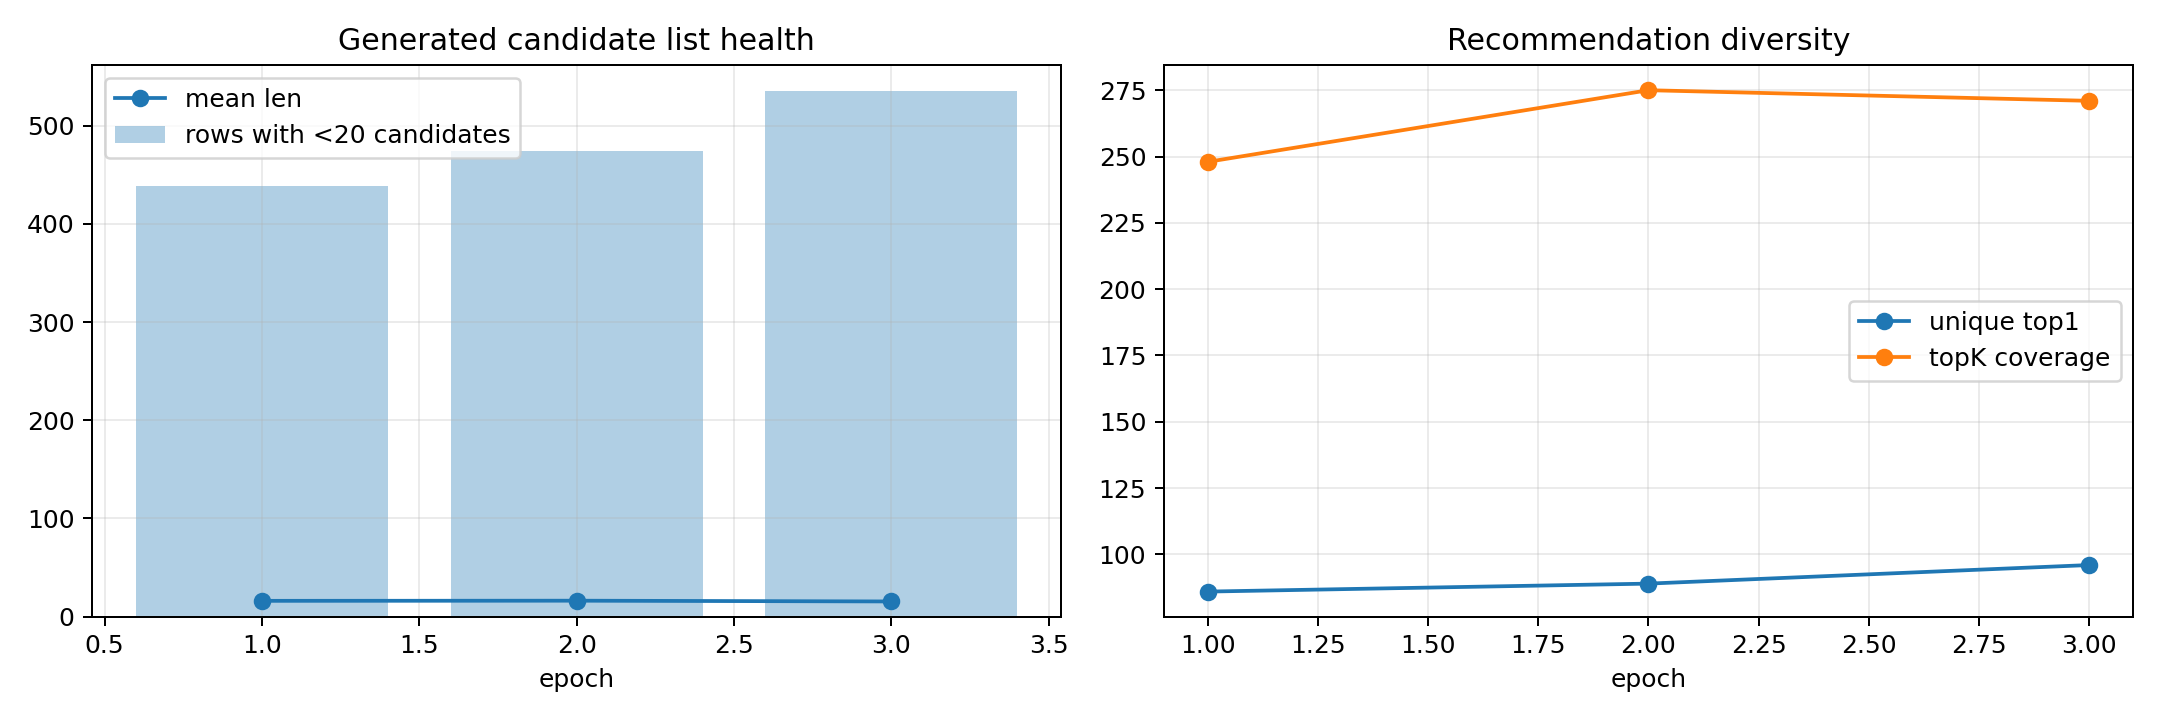

In [15]:
# Medium SFT diagnostics across epochs.
show_png(report.plot_sft_diagnostics(sft_diagnostics))

**Комментарий.** Teacher-forcing loss падает, но ranking не улучшается убедительно. Это классический симптом несоответствия LM-objective и retrieval-objective: модель лучше предсказывает target SID tokens в teacher-forcing режиме, но beam search top-K остается недостаточно персонализированным и проигрывает популярности.

## 6. Каноничность относительно PLUM и решение по серии

**Что сделано по духу PLUM:**

- item -> Semantic ID tokenization;
- LLM tokenizer расширен SID/user/schema tokens;
- CPT на user behavior + item metadata;
- SFT как `p(SID_next | user/history prompt)`;
- trie-constrained beam decoding, invalid SID rate `0.0`;
- ranking evaluation через Recall/NDCG/MRR.

**Что не канонично / слабее оригинального PLUM:**

- нет industrial multi-modal video representation;
- SID-v2 реализован как MovieLens surrogate, не production multimodal SID;
- SFT labels не семплированы по engagement/satisfaction reward;
- `MAX_LENGTH=512`, тогда как в PLUM было около 1536 tokens и примерно 100 watches;
- текущая SFT-серия использует только `5` train targets/user вместо полноценного supervised sliding-window корпуса;
- нет сильных sequential baselines в основном leaderboard;
- Medium monitor считал `Recall@20` при `RECSYS_BEAMS=10`.

**Решение.** Текущую SFT-серию правильно закрыть как negative result. Она полезна как проверка end-to-end pipeline, но не как направление для продолжения без изменения постановки.

## 7. Рекомендуемый дальнейший план

1. Зафиксировать этот notebook как отчет по текущему состоянию и negative result по SFT.
2. Добавить leaderboard-бейзлайны: Popularity, ItemKNN/co-occurrence, GRU4Rec/SASRec.
3. Если возвращаться к PLUM-style SFT, начинать новую серию:
   - `MAX_LENGTH=1024`;
   - `RECSYS_BEAMS >= 20`, лучше `50` для final eval;
   - full sliding-window train examples, а не `5` targets/user;
   - отдельно логировать `Recall@10`, `NDCG@10`, coverage, novelty/popularity bias;
   - сравнивать каждую эпоху с popularity и ItemKNN.
4. Не тратить compute на дополнительные эпохи текущего Medium SFT без этих изменений.